In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [3]:
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

print('Dataset Shape:')
print(df.shape)

print('\nFirst 5 rows:')
df.head()

Dataset Shape:
(64374, 12)

First 5 rows:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


## Data Explore

In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


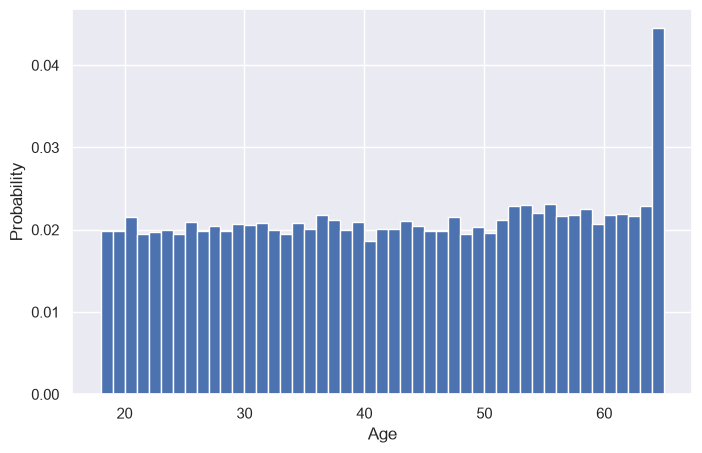

In [43]:
fig , ax = plt.subplots(figsize=(8,5))
ax.hist(
    df['Age'], bins=(df['Age'].max() - df['Age'].min()), density=True
)
ax.set_xlabel('Age')
ax.set_ylabel('Probability')
plt.show()

#### <b> Age Distribution Observation </b>

The age distribution shows an unusual increase at Age = 65, where the number of observations is significantly higher than other ages. This suggests that 65 may represent a grouped value rather than only people who are exactly 65 years old.

A possible explanation is top-coding, where all ages above a certain threshold (e.g., 65+) are recorded as 65. Therefore, this value should be treated carefully during analysis and modeling, as it may represent a range of ages rather than a single age group.

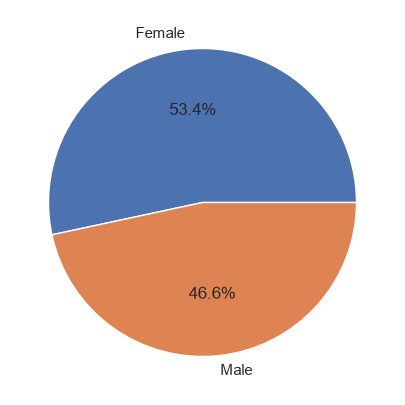

In [ ]:
df_gender = df['Gender'].value_counts().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.pie(df_gender['count'], labels=df_gender['Gender'],autopct='%1.1f%%', startangle=140, explode=[0,0.05])
plt.show()

In [ ]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn"):
        grp[col].plot.kde(ax=ax, label=["No Churn","Churn"][label], linewidth=2)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_numeric_dist.png")
plt.show()

## Cleaning Data

In [3]:
print('\nMissing values:')
print(df.isnull().sum())

print('\nTarget distribution:')
print(df['Churn'].value_counts(normalize=True))


Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Target distribution:
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

lbe_gender = LabelEncoder()
lbe_gender.fit(X['Gender'].drop_duplicates())
X['Gender'] = lbe_gender.transform(X['Gender'])

lbe_subscriptiontype = LabelEncoder()
lbe_subscriptiontype.fit(X['Subscription Type'].drop_duplicates())
X['Subscription Type'] = lbe_subscriptiontype.transform(X['Subscription Type'])


lbe_Contract = LabelEncoder()
lbe_Contract.fit(X['Contract Length'].drop_duplicates())

X['Contract Length'] = lbe_Contract.transform(X['Contract Length'])

X.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,1,22,0,25,14,4,27,0,1,598,9
1,2,41,0,28,28,7,13,2,1,584,20
2,3,47,1,27,10,2,29,1,0,757,21
3,4,35,1,9,12,5,17,1,2,232,18
4,5,53,0,58,24,9,2,2,0,533,18


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)

print(X_test.shape)

(51499, 11)
(12875, 11)


In [11]:
model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
print(accuracy_score(y_test, y_pred))

0.9980582524271845